# TASK 2: DISTRIBUTION TESTING


## Setup: Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn dcor warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from IPython.display import display

# Statistical tests
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest, chi2_contingency, chisquare

# Configuration
import warnings
warnings.filterwarnings('ignore')

print("OK Libraries imported successfully")

OK Libraries imported successfully


## Visualization Configuration

In [43]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.0)

plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (12, 8),
    'axes.titlesize': 14,
    'axes.labelsize': 11
})

print("OK Visualization configured")

OK Visualization configured


---

## Section 2.1: Data Loading

Load dataset and identify relevant variables.

In [44]:
# Load data
df = pd.read_csv('Life_style_data.csv')

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 3 rows:")
display(df.head(3))

# Check for required variables
required_vars = ['Gender', 'Workout_Type', 'Calories_Burned']
missing_vars = [v for v in required_vars if v not in df.columns]

if missing_vars:
    print(f"\nWARNING: Missing variables: {missing_vars}")
else:
    print(f"\nOK All required variables present")

DATA LOADING
Dataset shape: (20000, 54)

First 3 rows:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High



OK All required variables present


---

## Section 2.2: Categorical Distribution Analysis

### 2.2.1: Univariate Distributions

Examine each variable separately first.

UNIVARIATE DISTRIBUTION ANALYSIS


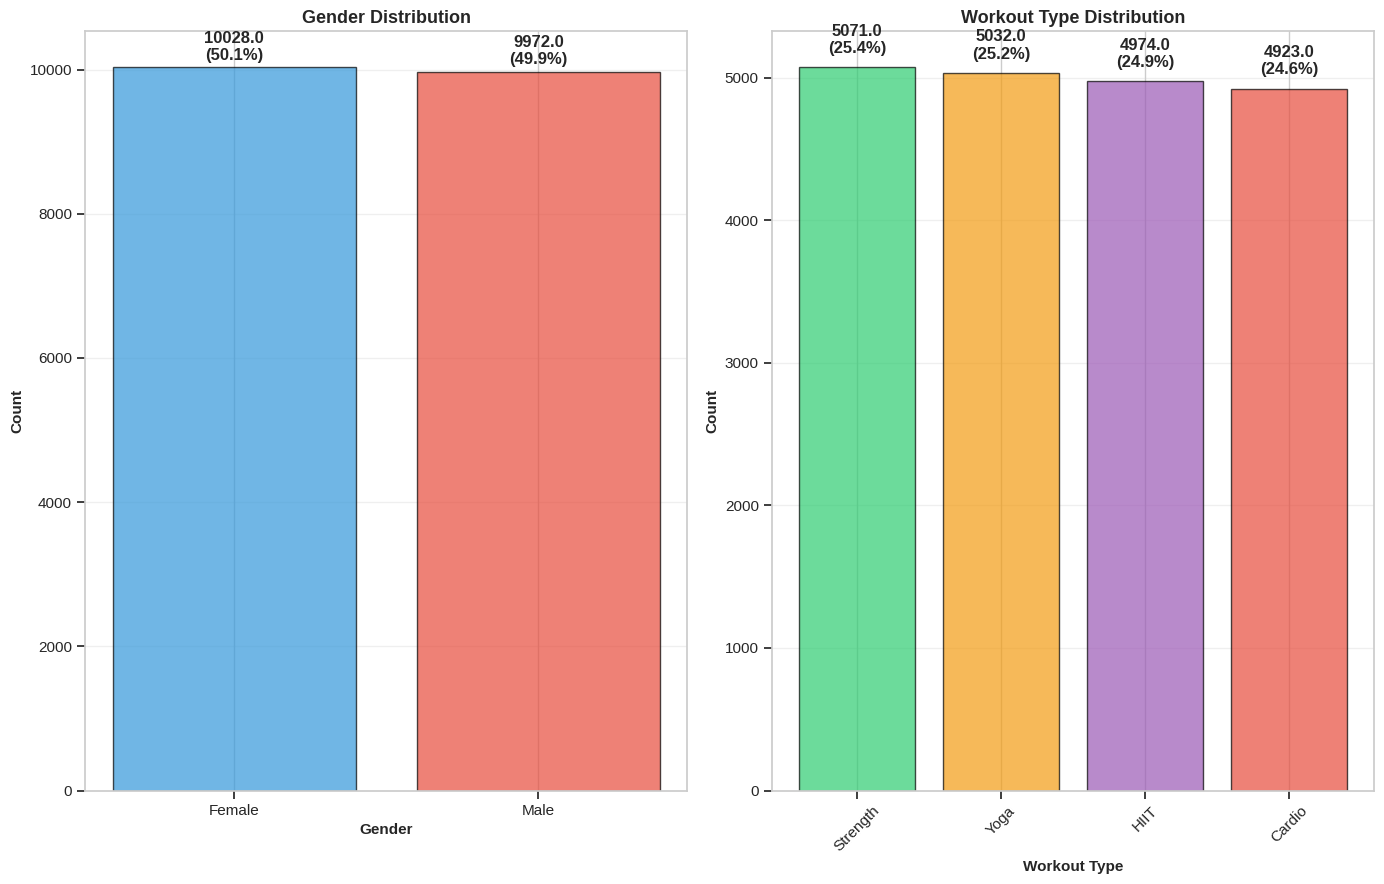

In [45]:
print("="*80)
print("UNIVARIATE DISTRIBUTION ANALYSIS")
print("="*80)

# Gender distribution
gender_counts = df['Gender'].value_counts()
gender_pct = df['Gender'].value_counts(normalize=True) * 100

gender_df = pd.DataFrame({
    'Count': gender_counts,
    'Percentage': gender_pct
})

# Workout Type distribution
workout_counts = df['Workout_Type'].value_counts()
workout_pct = df['Workout_Type'].value_counts(normalize=True) * 100

workout_df = pd.DataFrame({
    'Count': workout_counts,
    'Percentage': workout_pct
})
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

# Gender bar chart
axes[0].bar(gender_df.index, gender_df['Count'],
            color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Gender', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Count', fontweight='bold', fontsize=11)
axes[0].set_title('Gender Distribution', fontweight='bold', fontsize=13)
for i, (idx, row) in enumerate(gender_df.iterrows()):
    axes[0].text(i, row['Count'] + 100, f"{row['Count']}\n({row['Percentage']:.1f}%)",
                 ha='center', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Workout Type bar chart
colors_workout = ['#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']
axes[1].bar(workout_df.index, workout_df['Count'],
            color=colors_workout[:len(workout_df)], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Workout Type', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Count', fontweight='bold', fontsize=11)
axes[1].set_title('Workout Type Distribution', fontweight='bold', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
for i, (idx, row) in enumerate(workout_df.iterrows()):
    axes[1].text(i, row['Count'] + 100, f"{row['Count']}\n({row['Percentage']:.1f}%)",
                 ha='center', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Dis_gen_wor.png', dpi=450, bbox_inches='tight')
plt.show()

### 2.2.2: Statistical Test for Uniform Distribution (Goodness of Fit)

In [54]:
def test_uniformity(df, column_name):
    # 1. Get Observed Counts
    observed_counts = df[column_name].value_counts()

    # 2. Perform Test (Default expected frequencies = Uniform)
    chi2_stat, p_value = chisquare(observed_counts)

    # 3. Display Results
    print(f"--- Uniformity Test: {column_name} ---")
    print(f"Observed Counts:\n{observed_counts}")
    print(f"Chi-square Statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

print("="*80)
print("STATISTICAL GOODNESS OF FIT TEST")
print("="*80 + "\n")

# Run test for Gender
test_uniformity(df, 'Gender')

# Run test for Workout_Type
test_uniformity(df, 'Workout_Type')

STATISTICAL GOODNESS OF FIT TEST

--- Uniformity Test: Gender ---
Observed Counts:
Gender
Female    10028
Male       9972
Name: count, dtype: int64
Chi-square Statistic: 0.1568
P-value: 0.6921
--- Uniformity Test: Workout_Type ---
Observed Counts:
Workout_Type
Strength    5071
Yoga        5032
HIIT        4974
Cardio      4923
Name: count, dtype: int64
Chi-square Statistic: 2.5340
P-value: 0.4692


### 2.2.3: Contingency Table (Cross-tabulation)

**Contingency Table:** Shows the frequency distribution of two categorical variables.

In [47]:
print("="*80)
print("CONTINGENCY TABLE: GENDER vs WORKOUT TYPE")
print("="*80)

# Create contingency table
contingency_table = pd.crosstab(
    df['Gender'],
    df['Workout_Type'],
    margins=True,
    margins_name='Total'
)

print("\n1. OBSERVED FREQUENCIES (Counts)")
print("-"*80)


display(contingency_table.style
        .set_caption("Observed Frequencies (Counts)")
        .background_gradient(cmap='YlGnBu', subset=pd.IndexSlice[contingency_table.index[:-1], contingency_table.columns[:-1]])
        .format('{:,.0f}') # Format counts with comma separator
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

# Row percentages (by Gender)
row_pct = pd.crosstab(
    df['Gender'],
    df['Workout_Type'],
    normalize='index'
) * 100

print("\n2. ROW PERCENTAGES (Within each Gender)")
print("-"*80)
print("What % of each Gender chooses each Workout Type?")
display(row_pct.round(2).style
        .set_caption("Row Percentages (Within each Gender)")
        .format("{:.2f}%")
        .background_gradient(cmap='Greens')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

# Column percentages (by Workout Type)
col_pct = pd.crosstab(
    df['Gender'],
    df['Workout_Type'],
    normalize='columns'
) * 100

print("\n3. COLUMN PERCENTAGES (Within each Workout Type)")
print("-"*80)
print("What % of each Workout Type is done by each Gender?")
display(col_pct.round(2).style
        .set_caption("Column Percentages (Within each Workout Type)")
        .format("{:.2f}%")
        .background_gradient(cmap='Oranges')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

# Overall percentages
overall_pct = pd.crosstab(
    df['Gender'],
    df['Workout_Type'],
    normalize='all'
) * 100

print("\n4. OVERALL PERCENTAGES (Of total sample)")
print("-"*80)
display(overall_pct.round(2).style
        .set_caption("Overall Percentages (Of total sample)")
        .format("{:.2f}%")
        .background_gradient(cmap='Purples')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

CONTINGENCY TABLE: GENDER vs WORKOUT TYPE

1. OBSERVED FREQUENCIES (Counts)
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga,Total
Gender,,,,,
Female,"2,418","2,479","2,601","2,530","10,028"
Male,"2,505","2,495","2,470","2,502","9,972"
Total,"4,923","4,974","5,071","5,032","20,000"



2. ROW PERCENTAGES (Within each Gender)
--------------------------------------------------------------------------------
What % of each Gender chooses each Workout Type?


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,24.11%,24.72%,25.94%,25.23%
Male,25.12%,25.02%,24.77%,25.09%



3. COLUMN PERCENTAGES (Within each Workout Type)
--------------------------------------------------------------------------------
What % of each Workout Type is done by each Gender?


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,49.12%,49.84%,51.29%,50.28%
Male,50.88%,50.16%,48.71%,49.72%



4. OVERALL PERCENTAGES (Of total sample)
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,12.09%,12.40%,13.00%,12.65%
Male,12.52%,12.48%,12.35%,12.51%


In [48]:
print("="*80)
print("DESCRIPTIVE STATISTICS - CATEGORICAL VARIABLES".center(80))
print("="*80 + "\n")

categorical_cols = ['Gender', 'Workout_Type'] # Define categorical columns based on previous analysis

for col in categorical_cols:
    print(f"\n{col}:")
    print("-"*40)
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        'Frequency': freq,
        'Percentage': pct.round(2)
    })

    # Convert the index (e.g., 'Gender') into a regular column
    result = result.reset_index()
    # Rename the new column to be consistent with the original categorical variable name
    result = result.rename(columns={'index': col})

    # Styled display
    styled_result = result.style\
        .background_gradient(cmap='Blues', subset=['Frequency']) \
        .background_gradient(cmap='Greens', subset=['Percentage']) \
        .format({'Frequency': '{:,}', 'Percentage': '{:.2f}%'}) \
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }) \
        .set_caption(f"{col} Distribution")

    display(styled_result)
    print(f"Mode: {df[col].mode()[0]}")
    print(f"Unique values: {df[col].nunique()}")

                 DESCRIPTIVE STATISTICS - CATEGORICAL VARIABLES                 


Gender:
----------------------------------------


,Gender,Frequency,Percentage
0,Female,"10,028",50.14%
1,Male,"9,972",49.86%


Mode: Female
Unique values: 2

Workout_Type:
----------------------------------------


,Workout_Type,Frequency,Percentage
0,Strength,"5,071",25.36%
1,Yoga,"5,032",25.16%
2,HIIT,"4,974",24.87%
3,Cardio,"4,923",24.62%


Mode: Strength
Unique values: 4


### 2.2.4: Visual Analysis - Multiple Perspectives

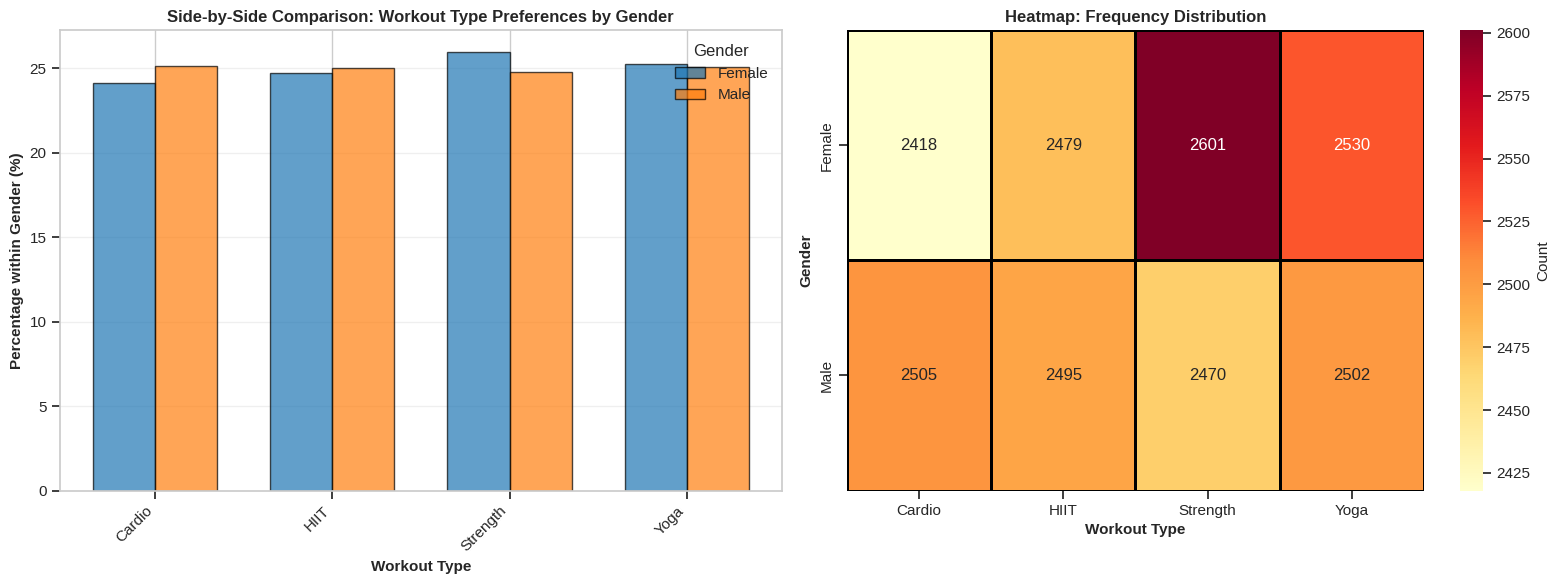

In [55]:
# Comprehensive visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
contingency_table_no_total = pd.crosstab(df['Gender'], df['Workout_Type'])

# 1. Side-by-side percentage comparison
ax3 = axes[0]
x = np.arange(len(row_pct.columns))
width = 0.35
genders = row_pct.index.tolist()

for i, gender in enumerate(genders):
    offset = width * (i - 0.5)
    ax3.bar(x + offset, row_pct.loc[gender], width,
            label=gender, alpha=0.7, edgecolor='black')

ax3.set_xlabel('Workout Type', fontweight='bold', fontsize=11)
ax3.set_ylabel('Percentage within Gender (%)', fontweight='bold', fontsize=11)
ax3.set_title('Side-by-Side Comparison: Workout Type Preferences by Gender',
              fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(row_pct.columns, rotation=45, ha='right')
ax3.legend(title='Gender')
ax3.grid(alpha=0.3, axis='y')

# 2. Heatmap
ax4 = axes[1]
sns.heatmap(contingency_table_no_total, annot=True, fmt='d', cmap='YlOrRd',
            ax=ax4, cbar_kws={'label': 'Count'}, linewidths=1, linecolor='black')
ax4.set_xlabel('Workout Type', fontweight='bold', fontsize=11)
ax4.set_ylabel('Gender', fontweight='bold', fontsize=11)
ax4.set_title('Heatmap: Frequency Distribution', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('Gen_wor.png', dpi=450, bbox_inches='tight')
plt.show()

### 2.2.5: Expected Frequencies (Chi-square Assumption Check)

EXPECTED FREQUENCIES ANALYSIS

1. OBSERVED FREQUENCIES
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,"2,418","2,479","2,601","2,530"
Male,"2,505","2,495","2,470","2,502"



2. EXPECTED FREQUENCIES (If Gender and Workout Type were independent)
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,"2,468.4","2,494.0","2,542.6","2,523.0"
Male,"2,454.6","2,480.0","2,528.4","2,509.0"



3. DIFFERENCE (Observed - Expected)
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,-50.4,-15.0,58.4,7.0
Male,50.4,15.0,-58.4,-7.0


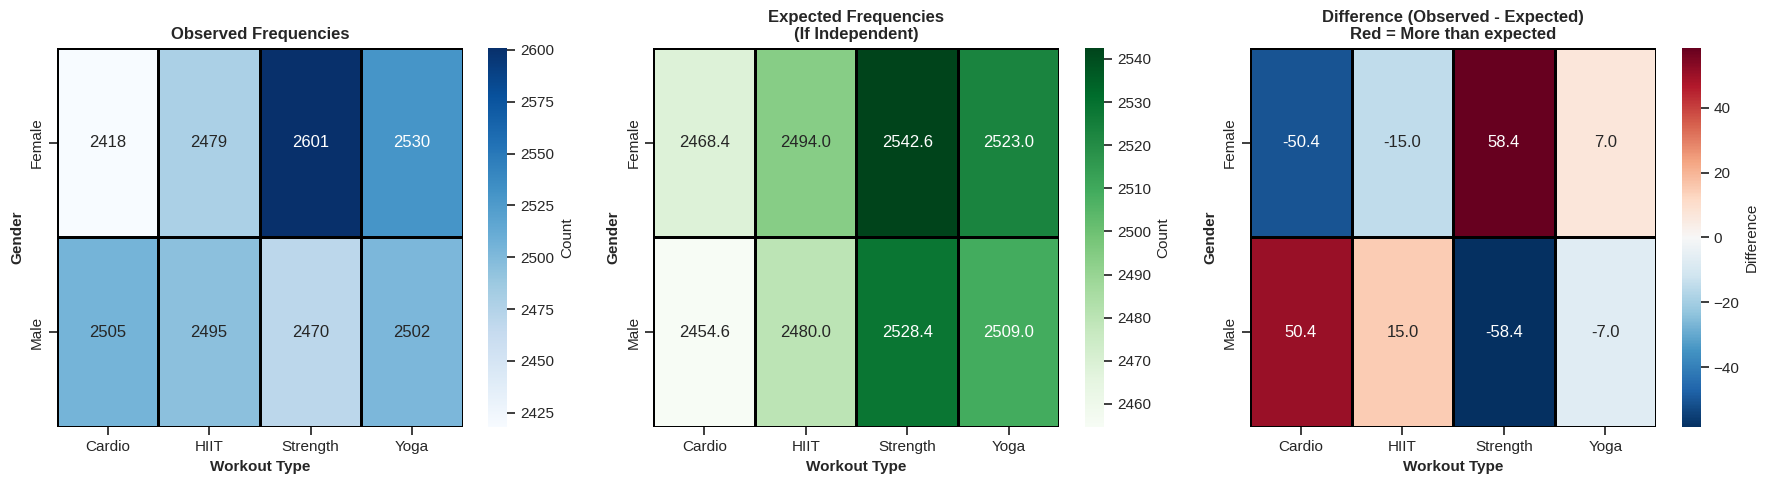


Interpretation of Differences:
  Positive (Red):  More observations than expected if independent
  Negative (Blue): Fewer observations than expected if independent
  Near Zero:       Close to what we'd expect if independent


In [50]:
print("="*80)
print("EXPECTED FREQUENCIES ANALYSIS")
print("="*80)

# Calculate expected frequencies
# Remove margins for calculation
observed = contingency_table.iloc[:-1, :-1]  # Remove 'Total' row and column

# Calculate expected frequencies using chi2_contingency
chi2, p, dof, expected = chi2_contingency(observed)
expected_df = pd.DataFrame(expected,
                           index=observed.index,
                           columns=observed.columns)

print("\n1. OBSERVED FREQUENCIES")
print("-"*80)
display(observed.style
        .set_caption("Observed Frequencies (Counts)")
        .format('{:,.0f}') # Format counts with comma separator
        .background_gradient(cmap='Blues')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

print("\n2. EXPECTED FREQUENCIES (If Gender and Workout Type were independent)")
print("-"*80)
display(expected_df.round(1).style # Round for display consistency with heatmap
        .set_caption("Expected Frequencies (If Independent)")
        .format('{:,.1f}')
        .background_gradient(cmap='Greens')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

print("\n3. DIFFERENCE (Observed - Expected)")
print("-"*80)
difference = observed - expected_df
display(difference.round(1).style # Round for display consistency with heatmap
        .set_caption("Difference (Observed - Expected)")
        .format('{:,.1f}')
        .background_gradient(cmap='RdBu_r') # Removed 'center=0' argument
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

# Visualize observed vs expected
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Observed
sns.heatmap(observed, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='black')
axes[0].set_title('Observed Frequencies', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Workout Type', fontweight='bold')
axes[0].set_ylabel('Gender', fontweight='bold')

# Expected
sns.heatmap(expected_df, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='black')
axes[1].set_title('Expected Frequencies\n(If Independent)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Workout Type', fontweight='bold')
axes[1].set_ylabel('Gender', fontweight='bold')

# Difference
sns.heatmap(difference, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=axes[2],
            cbar_kws={'label': 'Difference'}, linewidths=1, linecolor='black')
axes[2].set_title('Difference (Observed - Expected)\nRed = More than expected',
                  fontweight='bold', fontsize=12)
axes[2].set_xlabel('Workout Type', fontweight='bold')
axes[2].set_ylabel('Gender', fontweight='bold')

plt.tight_layout()
plt.savefig('oed.png', dpi=450, bbox_inches='tight')
plt.show()

print("\nInterpretation of Differences:")
print("  Positive (Red):  More observations than expected if independent")
print("  Negative (Blue): Fewer observations than expected if independent")
print("  Near Zero:       Close to what we'd expect if independent")